
# Triadic Cell Notebook v32
## Breathing beam controller

This notebook adds the missing inhale / exhale mechanic.

The prior recursive notebook proved that a single chosen branch can fold inward and reduce
missing mass. But it could not improve class identity because it only recursed inside the
current winner.

v32 adds a breathing beam:

- **inhale**
  - keep multiple candidate basins alive
  - spawn alternatives from the current branch states

- **exhale**
  - let each branch fold inward for a small number of steps
  - recompute missing, retrieve, contradiction, and declaration

Then re-rank and prune.

This turns the runtime from:

$$
Q \to \text{best class} \to \text{recurse}
$$

into:

$$
Q \to \{\text{top-}k\text{ classes}\} \to \text{fold each} \to \text{re-rank} \to \text{collapse late}
$$



## Practical meaning

This is still runtime control, not base-model training.

The key question is whether recursion can improve identity once multiple alternatives
are allowed to survive and compete through time.

The key outputs are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `beam_trace_df`


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Directional basis


In [3]:

raw_basis = np.array([
    [1.0, 0.0, 0.6, 0.2, 0.0, 0.3],
    [0.2, 1.0, 0.0, 0.6, 0.2, 0.0],
    [0.0, 0.2, 1.0, 0.0, 0.6, 0.2],
    [0.6, 0.0, 0.2, 1.0, 0.0, 0.6],
    [0.0, 0.6, 0.2, 0.0, 1.0, 0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)


## Query corruption


In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Directional decomposition


In [5]:

def directional_coeffs(x: np.ndarray):
    return U @ x

def reconstruct_from_coeffs(c: np.ndarray):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query: np.ndarray, target: np.ndarray):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    active_dirs = int(np.sum(np.abs(aq) > 0.10))
    boundary_complexity = int(np.sum(np.abs(at) > 0.12))
    boundary_eff = max(1.0, boundary_complexity / 2.0)
    nyquist_score = float(active_dirs / boundary_eff)

    return {
        "R": R,
        "M": M,
        "E": E,
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
        "aligned_ratio": float(aligned_energy / total_energy),
        "nyquist_score": nyquist_score,
    }



## Candidate evaluation


In [6]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.25 * (1.0 - retrieve_fit)
        + 0.20 * max(0.0, 1.0 - split["nyquist_score"])
    )

    closure_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.90 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.50 * bridge_energy
    )

    declaration_score = closure_score + 0.18 * min(split["nyquist_score"], 2.0)

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "closure_score": float(closure_score),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "missing_ratio": split["missing_ratio"],
        "excess_ratio": split["excess_ratio"],
        "nyquist_score": split["nyquist_score"],
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin



## Calibration


In [7]:

rows = []
n_per_class = 700

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, all_results, margin = triadic_query(q)
        rows.append({
            "query": q,
            "true_class": cls,
            "query_mode": mode,
            "declaration_score": best["declaration_score"],
        })

world_df = pd.DataFrame(rows)

perm = rng.permutation(len(world_df))
split = int(0.5 * len(world_df))
cal_df = world_df.iloc[perm[:split]].reset_index(drop=True)
eval_df = world_df.iloc[perm[split:]].reset_index(drop=True)

target_retrieve_fraction = 0.35
retrieve_threshold = float(cal_df["declaration_score"].quantile(1.0 - target_retrieve_fraction))
retrieve_threshold


1.2780704554873628


## Field emission


In [8]:

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def produce_fields_for_class(query: np.ndarray, cls: int, threshold: float):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)

    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])

    mode = "retrieve" if ev["declaration_score"] >= threshold else "grow"

    closure_permission = sigmoid(8.0 * (ev["declaration_score"] - threshold))
    nyquist_permission = sigmoid(5.0 * (ev["nyquist_score"] - 1.0))
    margin_permission = sigmoid(10.0 * (margin - 0.05))
    permission = float(closure_permission * nyquist_permission * margin_permission)

    retrieve_mask = normalize01(ev["R"] * permission)
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]
    fold_field = normalize01(0.5 + 0.5 * signed_correction)

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    rank_score = (
        0.70 * ev["declaration_score"]
        + 0.20 * permission
        - 0.35 * float(missing_mask.mean())
        - 0.10 * float(contradiction_mask.mean())
    )

    return {
        "predicted_class": cls,
        "mode": mode,
        "margin": margin,
        "retrieve_fit": ev["retrieve_fit"],
        "bridge_energy": ev["bridge_energy"],
        "closure_score": ev["closure_score"],
        "declaration_score": ev["declaration_score"],
        "nyquist_score": ev["nyquist_score"],
        "permission": permission,
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "fold_field": fold_field,
        "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
        "rank_score": float(rank_score),
    }

def produce_fields_best(query: np.ndarray, threshold: float):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"], threshold)



## Single-branch recursive baseline


In [9]:

def recursive_fold_branch(query: np.ndarray, cls: int, threshold: float, max_steps: int = 8, step_size: float = 0.45, damping: float = 0.85):
    q = query.copy()
    hist_rows = []

    for step in range(max_steps):
        f = produce_fields_for_class(q, cls, threshold)
        hist_rows.append({
            "step": step,
            "class": cls,
            "mode": f["mode"],
            "rank_score": f["rank_score"],
            "missing_mass": float(f["missing_mask"].mean()),
            "retrieve_mass": float(f["retrieve_mask"].mean()),
            "permission": f["permission"],
        })
        update = step_size * f["signed_correction"]
        q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

    final_fields = produce_fields_for_class(q, cls, threshold)
    return q, pd.DataFrame(hist_rows), final_fields

def single_branch_recursive(query: np.ndarray, threshold: float):
    best, _, _ = triadic_query(query)
    return recursive_fold_branch(query, best["class"], threshold)



## Breathing beam


In [10]:

def top_candidate_classes(query: np.ndarray, k: int = 3):
    results = [triadic_evaluate(query, c) for c in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    return [r["class"] for r in results[:k]]

def breathing_beam(query: np.ndarray, threshold: float, beam_width: int = 3, cycles: int = 4, exhale_steps: int = 2, step_size: float = 0.45, damping: float = 0.85):
    init_classes = top_candidate_classes(query, k=beam_width)
    beam = [{"cls": cls, "query": query.copy(), "spawn_from": -1} for cls in init_classes]
    trace_rows = []

    for cycle in range(cycles):
        expanded = []

        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]

            # exhale inside current basin
            for _ in range(exhale_steps):
                f = produce_fields_for_class(q, cls, threshold)
                update = step_size * f["signed_correction"]
                q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

            expanded.append({"cls": cls, "query": q.copy(), "spawn_from": branch["spawn_from"]})

            # inhale alternatives from the current folded state
            for alt_cls in top_candidate_classes(q, k=min(2, n_classes)):
                if alt_cls != cls:
                    expanded.append({"cls": alt_cls, "query": q.copy(), "spawn_from": cls})

        scored = []
        for item in expanded:
            f = produce_fields_for_class(item["query"], item["cls"], threshold)
            scored.append({
                **item,
                "rank_score": f["rank_score"],
                "mode": f["mode"],
                "declaration_score": f["declaration_score"],
                "missing_mass": float(f["missing_mask"].mean()),
                "retrieve_mass": float(f["retrieve_mask"].mean()),
                "permission": f["permission"],
            })

        # keep best instance per class
        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["rank_score"] > best_per_class[cls]["rank_score"]:
                best_per_class[cls] = item

        beam = sorted(best_per_class.values(), key=lambda x: x["rank_score"], reverse=True)[:beam_width]

        for rank, item in enumerate(beam):
            trace_rows.append({
                "cycle": cycle,
                "beam_rank": rank,
                "class": item["cls"],
                "mode": item["mode"],
                "rank_score": item["rank_score"],
                "declaration_score": item["declaration_score"],
                "missing_mass": item["missing_mass"],
                "retrieve_mass": item["retrieve_mass"],
                "permission": item["permission"],
                "spawn_from": item["spawn_from"],
            })

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"], threshold)
    return final_best["query"], pd.DataFrame(trace_rows), final_fields



## Single breathing example


In [11]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

q_single, single_trace_df, single_final = single_branch_recursive(q0, retrieve_threshold)
q_beam, beam_trace_df, beam_final = breathing_beam(
    q0,
    retrieve_threshold,
    beam_width=3,
    cycles=4,
    exhale_steps=2,
    step_size=0.45,
    damping=0.85,
)

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "single_final_class": single_final["predicted_class"],
    "beam_final_class": beam_final["predicted_class"],
    "single_missing_mass": float(single_final["missing_mask"].mean()),
    "beam_missing_mass": float(beam_final["missing_mask"].mean()),
    "single_retrieve_mass": float(single_final["retrieve_mask"].mean()),
    "beam_retrieve_mass": float(beam_final["retrieve_mask"].mean()),
}])
single_example


,true_class,query_mode,single_final_class,beam_final_class,single_missing_mass,beam_missing_mass,single_retrieve_mass,beam_retrieve_mass
0,1,partial,3,3,0.95307,0.95307,0.04693,0.04693


In [12]:

beam_trace_df


,cycle,beam_rank,class,mode,rank_score,declaration_score,missing_mass,retrieve_mass,permission,spawn_from
0,0,0,3,grow,0.008517,0.515034,0.998240,0.001760,2.209557e-03,-1
1,0,1,0,grow,-0.241373,0.168517,0.999994,0.000005,1.648531e-05,-1
2,0,2,1,grow,-0.254030,-0.018445,0.666667,0.128202,1.668334e-07,-1
3,1,0,3,grow,0.112774,0.659742,0.993009,0.006991,7.003299e-03,-1
4,1,1,1,grow,-0.066560,0.248689,0.666664,0.165797,9.771113e-06,-1
5,1,2,0,grow,-0.096197,0.374960,0.999817,0.000183,4.062175e-04,-1
6,2,0,3,grow,0.197395,0.770901,0.979654,0.020345,1.687399e-02,-1
7,2,1,1,grow,0.071637,0.445374,0.666573,0.166718,2.102237e-04,-1
8,2,2,0,grow,0.014032,0.530641,0.998696,0.001304,2.226211e-03,-1
9,3,0,3,grow,0.271627,0.858690,0.953070,0.046930,3.348415e-02,-1



## Compare first pass vs single-branch vs breathing beam


In [13]:

rows_compare = []

for _, row in eval_df.iterrows():
    q = row["query"]
    true_class = int(row["true_class"])
    query_mode = row["query_mode"]

    first = produce_fields_best(q, retrieve_threshold)
    q_single, single_trace, single_final = single_branch_recursive(q, retrieve_threshold)
    q_beam, beam_trace, beam_final = breathing_beam(
        q,
        retrieve_threshold,
        beam_width=3,
        cycles=4,
        exhale_steps=2,
        step_size=0.45,
        damping=0.85,
    )

    rows_compare.append({
        "true_class": true_class,
        "query_mode": query_mode,
        "first_class": first["predicted_class"],
        "single_class": single_final["predicted_class"],
        "beam_class": beam_final["predicted_class"],
        "first_correct": int(first["predicted_class"] == true_class),
        "single_correct": int(single_final["predicted_class"] == true_class),
        "beam_correct": int(beam_final["predicted_class"] == true_class),
        "first_missing_mass": float(first["missing_mask"].mean()),
        "single_missing_mass": float(single_final["missing_mask"].mean()),
        "beam_missing_mass": float(beam_final["missing_mask"].mean()),
        "first_retrieve_mass": float(first["retrieve_mask"].mean()),
        "single_retrieve_mass": float(single_final["retrieve_mask"].mean()),
        "beam_retrieve_mass": float(beam_final["retrieve_mask"].mean()),
        "single_steps_used": int(len(single_trace)),
        "beam_cycles_used": int(beam_trace["cycle"].nunique()) if len(beam_trace) else 0,
    })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_class,single_class,beam_class,first_correct,single_correct,beam_correct,first_missing_mass,single_missing_mass,beam_missing_mass,first_retrieve_mass,single_retrieve_mass,beam_retrieve_mass,single_steps_used,beam_cycles_used
0,0,existing,0,0,0,1,1,1,0.155701,0.096915,0.099667,0.844299,0.903085,0.900333,8,4
1,1,noisy,1,1,1,1,1,1,0.361475,0.317034,0.317034,0.638524,0.682966,0.682966,8,4
2,1,inverse_hint,1,1,1,1,1,1,0.660515,0.544234,0.544234,0.339482,0.455766,0.455766,8,4
3,1,inverse_hint,1,1,1,1,1,1,0.395642,0.214208,0.214208,0.437690,0.619125,0.619125,8,4
4,2,inverse_hint,3,3,3,0,0,0,0.495890,0.434498,0.434498,0.504106,0.565501,0.565501,8,4



## Core comparison


In [14]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "single_branch_accuracy": float(compare_df["single_correct"].mean()),
    "breathing_beam_accuracy": float(compare_df["beam_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "single_branch_missing_mass": float(compare_df["single_missing_mass"].mean()),
    "breathing_beam_missing_mass": float(compare_df["beam_missing_mass"].mean()),
}])
compare_summary


,first_pass_accuracy,single_branch_accuracy,breathing_beam_accuracy,first_pass_missing_mass,single_branch_missing_mass,breathing_beam_missing_mass
0,0.872143,0.872143,0.88,0.425414,0.335766,0.309323


In [15]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct",
        "single_correct",
        "beam_correct",
        "first_missing_mass",
        "single_missing_mass",
        "beam_missing_mass",
        "first_retrieve_mass",
        "single_retrieve_mass",
        "beam_retrieve_mass",
        "single_steps_used",
    ]]
    .mean()
    .reset_index()
)

by_mode_compare["single_accuracy_gain"] = by_mode_compare["single_correct"] - by_mode_compare["first_correct"]
by_mode_compare["beam_accuracy_gain"] = by_mode_compare["beam_correct"] - by_mode_compare["first_correct"]
by_mode_compare["beam_vs_single_gain"] = by_mode_compare["beam_correct"] - by_mode_compare["single_correct"]
by_mode_compare["beam_missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["beam_missing_mass"]

by_mode_compare = by_mode_compare.sort_values("beam_accuracy_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,single_correct,beam_correct,first_missing_mass,single_missing_mass,beam_missing_mass,first_retrieve_mass,single_retrieve_mass,beam_retrieve_mass,single_steps_used,single_accuracy_gain,beam_accuracy_gain,beam_vs_single_gain,beam_missing_drop
4,partial,0.620155,0.620155,0.635659,0.662506,0.567453,0.509968,0.336988,0.431251,0.480121,8.0,0.0,0.015504,0.015504,0.152538
2,inverse_hint,0.807143,0.807143,0.821429,0.582822,0.463633,0.449368,0.402877,0.508985,0.522060,8.0,0.0,0.014286,0.014286,0.133454
0,ambiguous,0.978355,0.978355,0.991342,0.619463,0.437277,0.432045,0.371157,0.554786,0.556411,8.0,0.0,0.012987,0.012987,0.187418
1,existing,1.000000,1.000000,1.000000,0.105301,0.081290,0.068652,0.890964,0.914975,0.920610,8.0,0.0,0.000000,0.000000,0.036649
3,noisy,1.000000,1.000000,1.000000,0.269847,0.194834,0.170075,0.723135,0.798733,0.819984,8.0,0.0,0.000000,0.000000,0.099772



## Partial-only focus


In [16]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()

partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_single_accuracy": float(partial_df["single_correct"].mean()),
    "partial_beam_accuracy": float(partial_df["beam_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_single_missing_mass": float(partial_df["single_missing_mass"].mean()),
    "partial_beam_missing_mass": float(partial_df["beam_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_single_retrieve_mass": float(partial_df["single_retrieve_mass"].mean()),
    "partial_beam_retrieve_mass": float(partial_df["beam_retrieve_mass"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_single_accuracy,partial_beam_accuracy,partial_first_missing_mass,partial_single_missing_mass,partial_beam_missing_mass,partial_first_retrieve_mass,partial_single_retrieve_mass,partial_beam_retrieve_mass
0,0.620155,0.620155,0.635659,0.662506,0.567453,0.509968,0.336988,0.431251,0.480121



## Visual readout


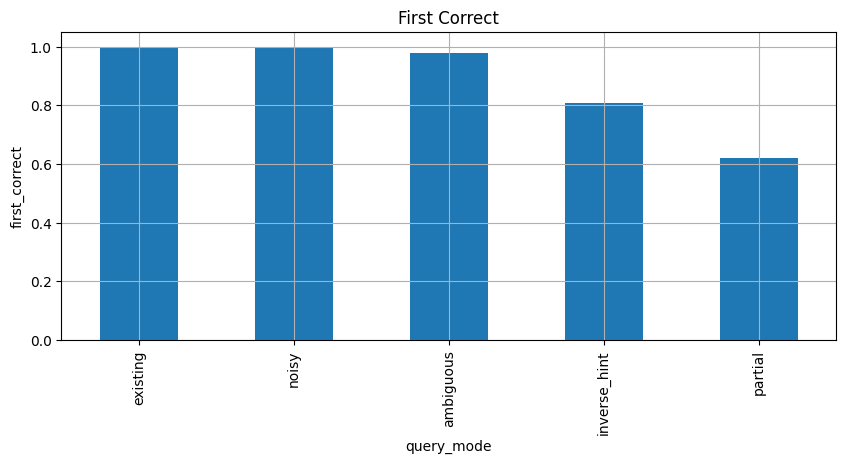

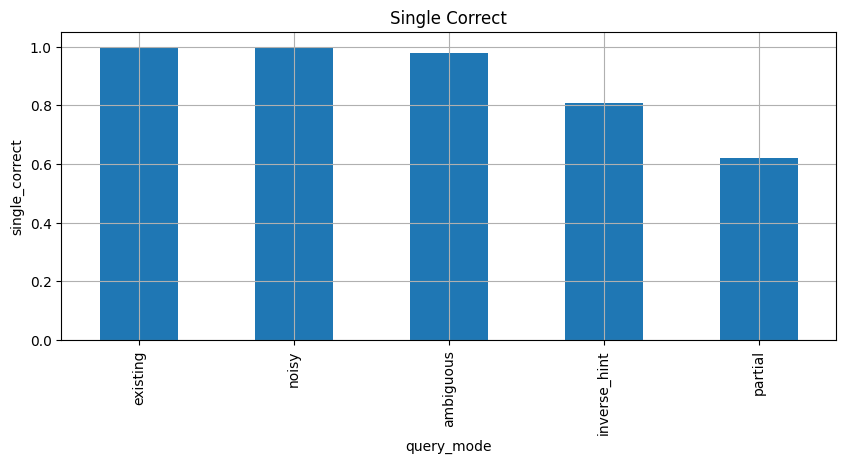

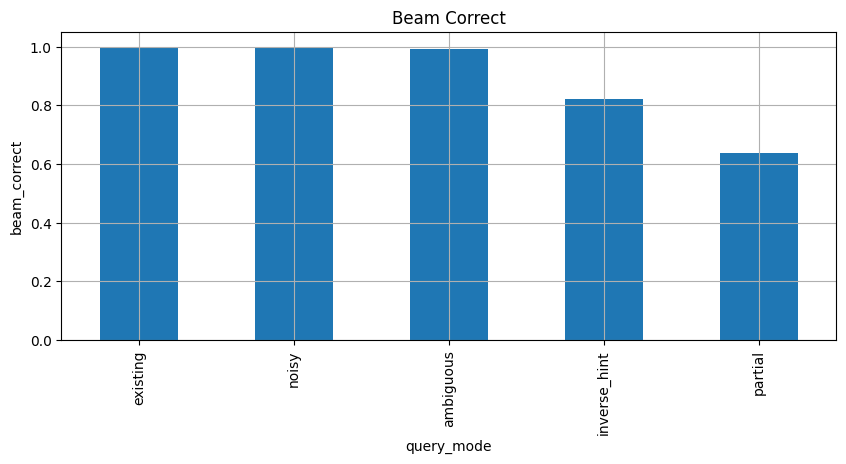

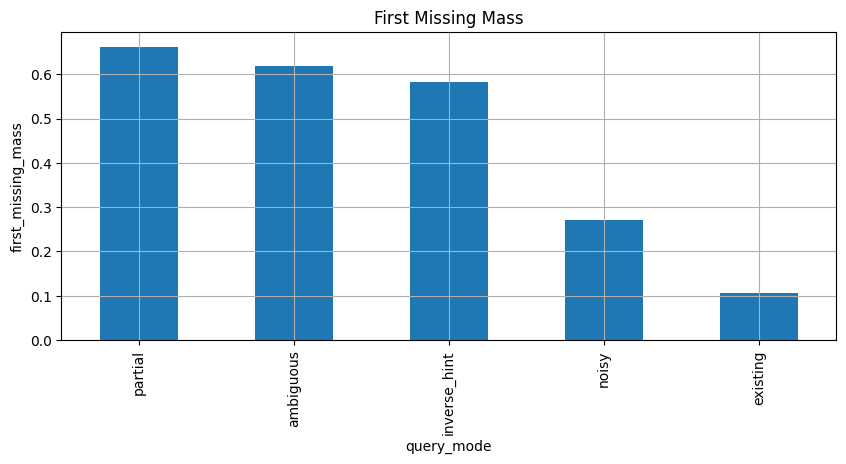

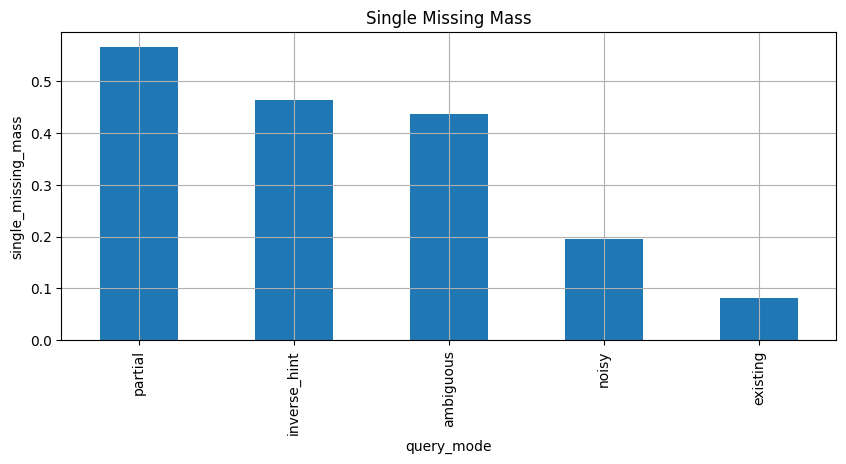

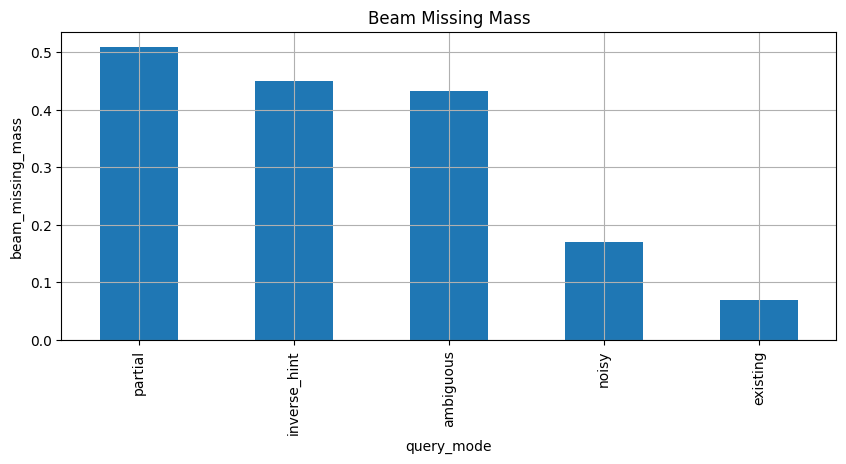

In [17]:

metrics = [
    "first_correct",
    "single_correct",
    "beam_correct",
    "first_missing_mass",
    "single_missing_mass",
    "beam_missing_mass",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()


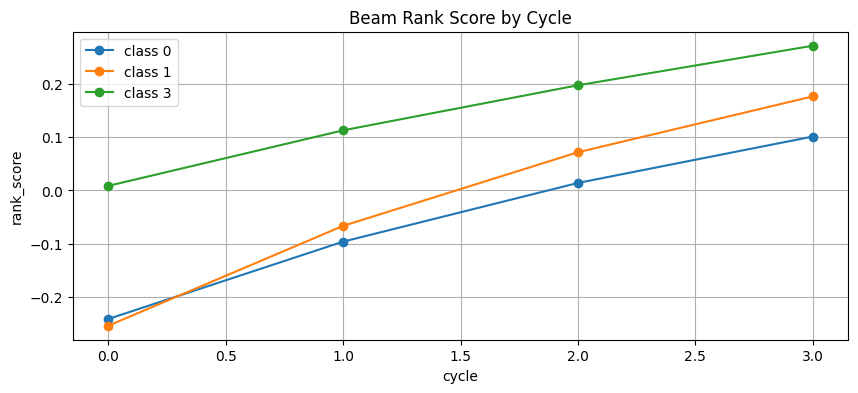

In [18]:

plt.figure(figsize=(10, 4))
for cls in sorted(beam_trace_df["class"].unique()):
    df = beam_trace_df[beam_trace_df["class"] == cls]
    plt.plot(df["cycle"], df["rank_score"], marker="o", label=f"class {cls}")
plt.title("Beam Rank Score by Cycle")
plt.xlabel("cycle")
plt.ylabel("rank_score")
plt.legend()
plt.show()



## Practical readout

This notebook adds the inhale / exhale mechanic:

- single-branch recursion = inward fold only
- breathing beam = keep alternatives alive, fold them, then re-rank

The first tables to read are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `beam_trace_df`
